Machine Learning Final Project Report
Project Title:
Predicting Mean Temperature from Daily Weather Metrics in Cornwall

Group Members:

Yashwant Bist 4367942
Ala ali sbai
Para Rawat

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Load the data set
The dataset was collected from Environment Canada, Minestry of Environment, for Cornwall weather station. It covers weather data for 2025 latest.

In [5]:
#load the dataset
df = pd.read_csv("cornwall_weather_report_2025.csv")

#display the intial 
print(df.head())
print(df.info())

   Longitude (x)  Latitude (y) Station Name  Climate ID Date/Time  Year  \
0         -74.75         45.02     CORNWALL     6101874  1/1/2025  2025   
1         -74.75         45.02     CORNWALL     6101874  1/2/2025  2025   
2         -74.75         45.02     CORNWALL     6101874  1/3/2025  2025   
3         -74.75         45.02     CORNWALL     6101874  1/4/2025  2025   
4         -74.75         45.02     CORNWALL     6101874  1/5/2025  2025   

   Month  Day Data Quality  Max Temp (°C)  ...  Total Snow (cm)  \
0      1    1            †            1.0  ...              2.0   
1      1    2            †            0.0  ...              0.0   
2      1    3            †           -4.0  ...              0.0   
3      1    4            †           -9.0  ...              2.0   
4      1    5            †          -10.5  ...              0.0   

   Total Snow Flag  Total Precip (mm)  Total Precip Flag  Snow on Grnd (cm)  \
0              NaN                5.8                NaN           

Dropping the initial empty rows 
#data cleaning & preprocessing

In [7]:
# Replace 'T' (Trace) with 0, and remove flag columns
df.replace('T', 0, inplace=True)
df = df.loc[:, ~df.columns.str.contains("Flag")]

# Convert numeric columns
cols_to_convert = ['Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 
                   'Total Rain (mm)', 'Total Snow (cm)', 'Total Precip (mm)',
                   'Snow on Grnd (cm)', 'Spd of Max Gust (km/h)']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing target
df = df.dropna(subset=['Mean Temp (°C)'])

In [8]:
# Create new features
df['Temp Range'] = df['Max Temp (°C)'] - df['Min Temp (°C)']
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Day of Week'] = df['Date/Time'].dt.dayofweek


Model Input and train split

In [9]:
features = ['Max Temp (°C)', 'Min Temp (°C)', 'Total Rain (mm)', 
            'Total Snow (cm)', 'Total Precip (mm)', 'Snow on Grnd (cm)', 
            'Temp Range', 'Day of Week']

X = df[features]
y = df['Mean Temp (°C)']

#datasplit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Model Training & evaluation


In [15]:
#linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Random Forest R²:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))


Random Forest R²: 0.9879226560807309
MAE: 0.585681632548739


In [16]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree R²:", r2_score(y_test, dt_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, dt_pred))


Decision Tree R²: 0.9382396631398854
Mean Absolute Error: 1.3631578947368421


In [17]:
#Random forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


print("LinearRegression R²:", r2_score(y_test, lr_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, lr_pred))



LinearRegression R²: 0.9999815810610717
Mean Absolute Error: 0.02321627857125564


In [18]:
def evaluate(y_true, y_pred, name):
    print(f"{name} R² Score:", r2_score(y_true, y_pred))
    print(f"{name} MAE:", mean_absolute_error(y_true, y_pred))

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, dt_pred, "Decision Tree")
evaluate(y_test, rf_pred, "Random Forest")


Linear Regression R² Score: 0.9999815810610717
Linear Regression MAE: 0.02321627857125564
Decision Tree R² Score: 0.9382396631398854
Decision Tree MAE: 1.3631578947368421
Random Forest R² Score: 0.9879226560807309
Random Forest MAE: 0.585681632548739


Visualizations


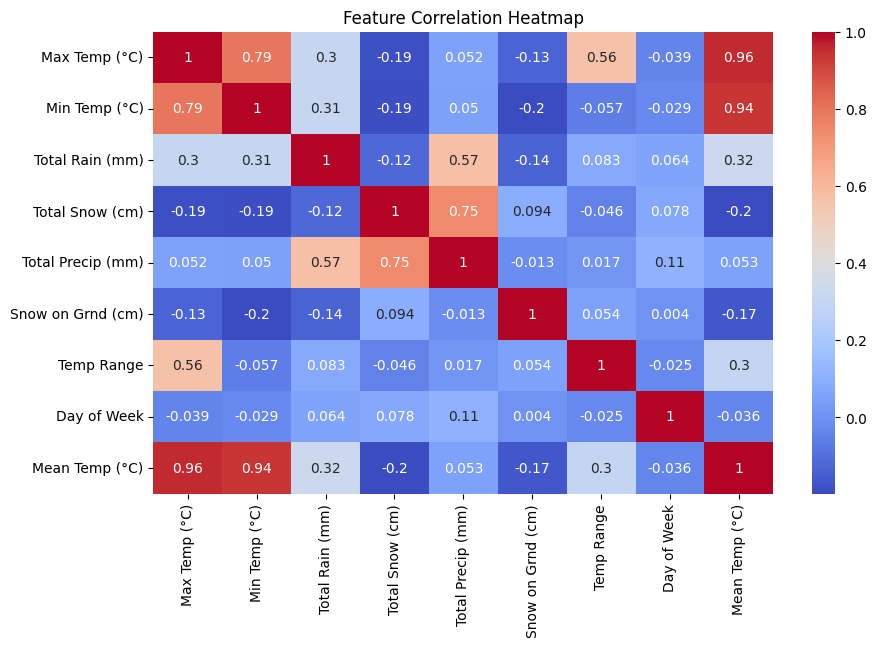

In [14]:
#correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[features + ['Mean Temp (°C)']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


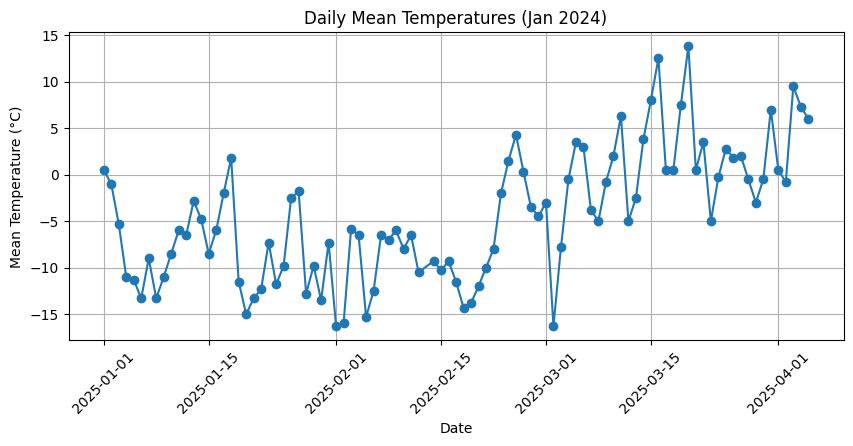

In [ ]:
#line plot of temperatures
plt.figure(figsize=(10, 4))
plt.plot(df["Date/Time"], df["Mean Temp (°C)"], marker='o')
plt.title("Daily Mean Temperatures")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


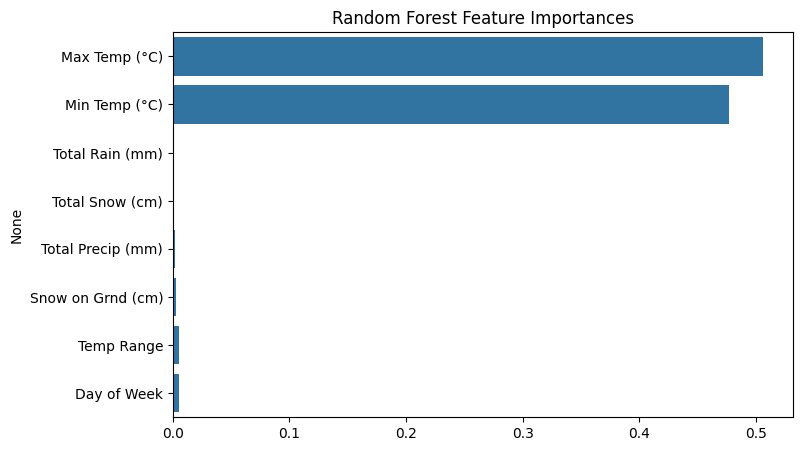

In [ ]:
#Features importance of random forest
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names)
plt.title("Random Forest Feature Importances")
plt.show()
